<h1>ECON 140 Section 3</h1>

**Simpson's Paradox with (fake) Berkeley data**

Today's teaching goals are:
- Show that the overall female admit rate can look lower, yet within each department females may have equal/higher admit rates. 
- The paradox arises because women apply more to tougher departments.

## Setup

We load the necessary libraries (e.g., `ggplot2`) and read in the fake Berkeley admissions dataset. This dataset contains:

- `gender`: “Female” or “Male”
- `admit`: 0/1 indicator (or “Admitted”/“Rejected”)
- `dept`: department label (e.g., “A”, “B”, …)


In [1]:
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/srv/r’
(as ‘lib’ is unspecified)



## Inspect the Data

We start by creating a dummy variable for female applicants (`female_dummy = 1 if Female, 0 otherwise`) and check that it’s coded correctly.  
We then use `head()`, `table()`, and `summary()` to peek at the data.


In [2]:
# Load data
d <- read.csv("berkeley_simpson_fake.csv", stringsAsFactors = FALSE)

# Create a female dummy (1 if Female, 0 otherwise)
d$female_dummy <- ifelse(d$gender == "Female", 1, 0)

# Basic inspection 
head(d)                                # peek at first rows
table(d$gender, d$female_dummy)        # cross-check dummy coding
summary(d)                             


,id,dept,gender,admit,female_dummy
,<int>,<chr>,<chr>,<int>,<dbl>
1,1,A,Male,0,0
2,2,A,Male,1,0
3,3,A,Male,1,0
4,4,A,Male,1,0
5,5,A,Male,1,0
6,6,A,Male,1,0


        
           0   1
  Female   0 300
  Male   400   0

       id            dept              gender              admit       
 Min.   :  1.0   Length:700         Length:700         Min.   :0.0000  
 1st Qu.:175.8   Class :character   Class :character   1st Qu.:0.0000  
 Median :350.5   Mode  :character   Mode  :character   Median :0.0000  
 Mean   :350.5                                         Mean   :0.4143  
 3rd Qu.:525.2                                         3rd Qu.:1.0000  
 Max.   :700.0                                         Max.   :1.0000  
  female_dummy   
 Min.   :0.0000  
 1st Qu.:0.0000  
 Median :0.0000  
 Mean   :0.4286  
 3rd Qu.:1.0000  
 Max.   :1.0000  

## Overall Admit Rates by Gender

This is where Simpson’s paradox often shows up:  
When we compute the *overall* admit rate by gender, we may see a lower rate for females compared to males.


In [3]:
overall_rates <- aggregate(admit ~ gender, data = d, mean)
overall_rates

gender,admit
<chr>,<dbl>
Female,0.3333333
Male,0.4750000


## Within-Department Admit Rates by Gender

To “hold department constant” we compute admit rates *inside* each department.  
This lets us see if women actually do as well or better than men when comparing like for like.

In [4]:
# Here we hold department "mix" constant by looking inside each dept.
within_rates <- aggregate(admit ~ dept + gender, data = d, mean)
within_rates


dept,gender,admit
<chr>,<chr>,<dbl>
A,Female,0.6
B,Female,0.4
C,Female,0.2
A,Male,0.6
B,Male,0.4
C,Male,0.2


## Application Mix by Gender

Next we look at who applies where.  
If one gender applies more to tougher departments, that can drive the overall gap.  
We tabulate the number of applicants by department and gender.


In [5]:
app_mix <- with(d, as.data.frame(table(dept, gender)))
names(app_mix)[3] <- "n_applicants"
app_mix


dept,gender,n_applicants
<fct>,<fct>,<int>
A,Female,50
B,Female,100
C,Female,150
A,Male,200
B,Male,150
C,Male,50


This reveals the *composition difference*: if one gender applies more to tougher departments, that can drive the overall gap.

## Visualizing Simpson’s Paradox

We create three kinds of plots:

1. **Overall admit rate by gender** (bars show mean of 0/1 admits).
2. **Within-department admit rate by gender** (faceted by department) to hold department mix constant.
3. **Applications by department and gender** (counts and shares) to show the composition difference.


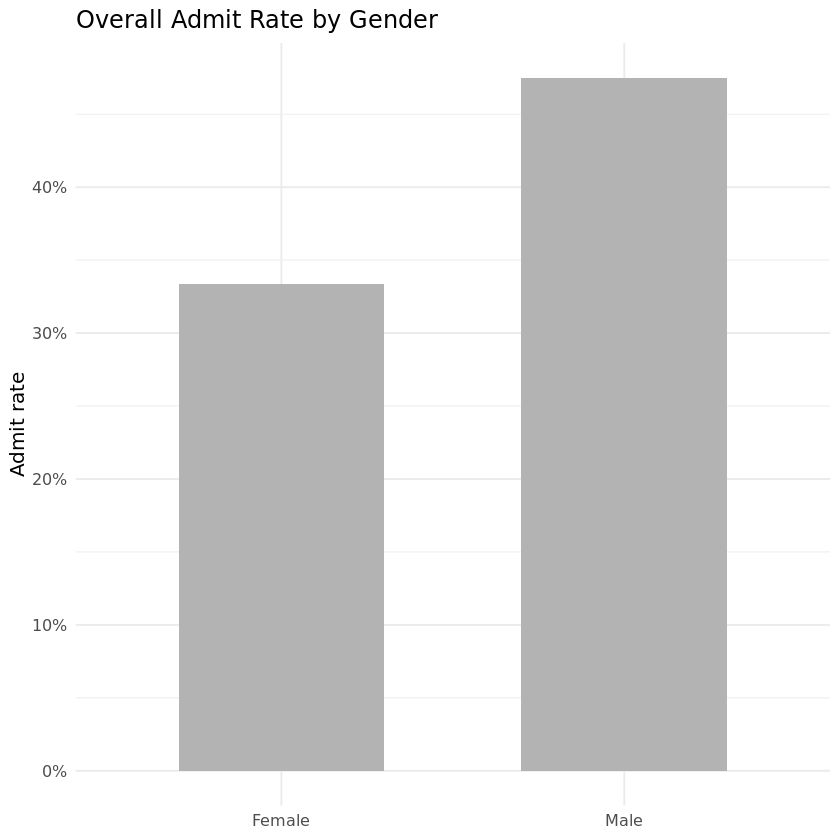

In [6]:
# A) Overall admit rate by gender (bars show the mean of 0/1 admits)
ggplot(d, aes(x = gender, y = admit)) +
  stat_summary(fun = mean, geom = "bar", fill = "grey70", width = 0.6) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Overall Admit Rate by Gender",
    x = NULL, y = "Admit rate"
  ) +
  theme_minimal(base_size = 12)


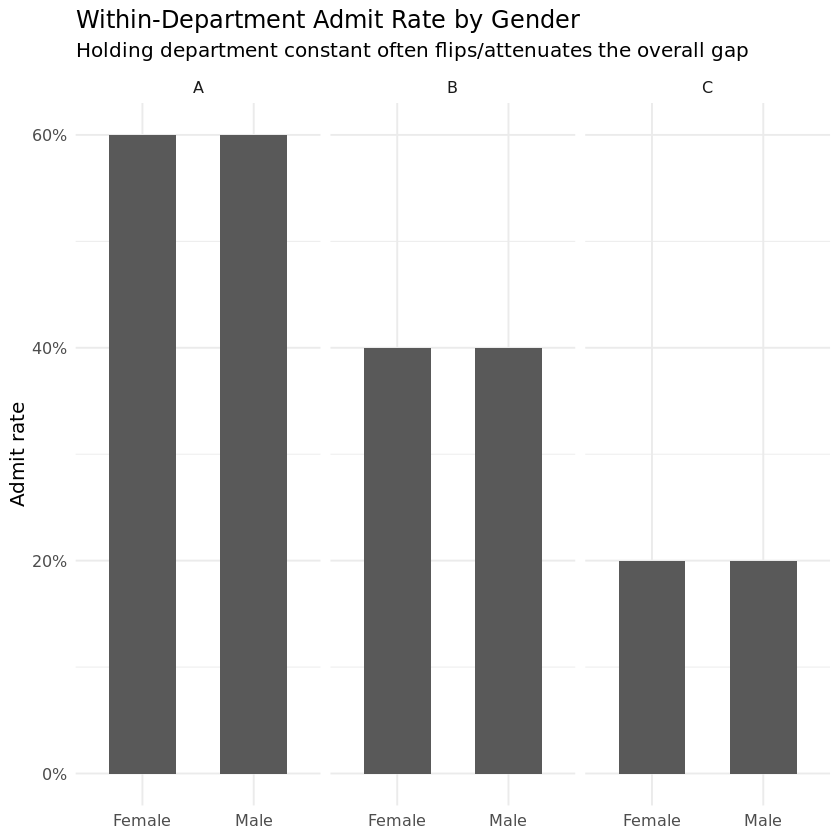

In [7]:
# B) Within-department admit rate by gender (facet by dept)
ggplot(d, aes(x = gender, y = admit)) +
  stat_summary(fun = mean, geom = "bar", width = 0.6) +
  facet_wrap(~ dept) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Within-Department Admit Rate by Gender",
    subtitle = "Holding department constant often flips/attenuates the overall gap",
    x = NULL, y = "Admit rate"
  ) +
  theme_minimal(base_size = 12)


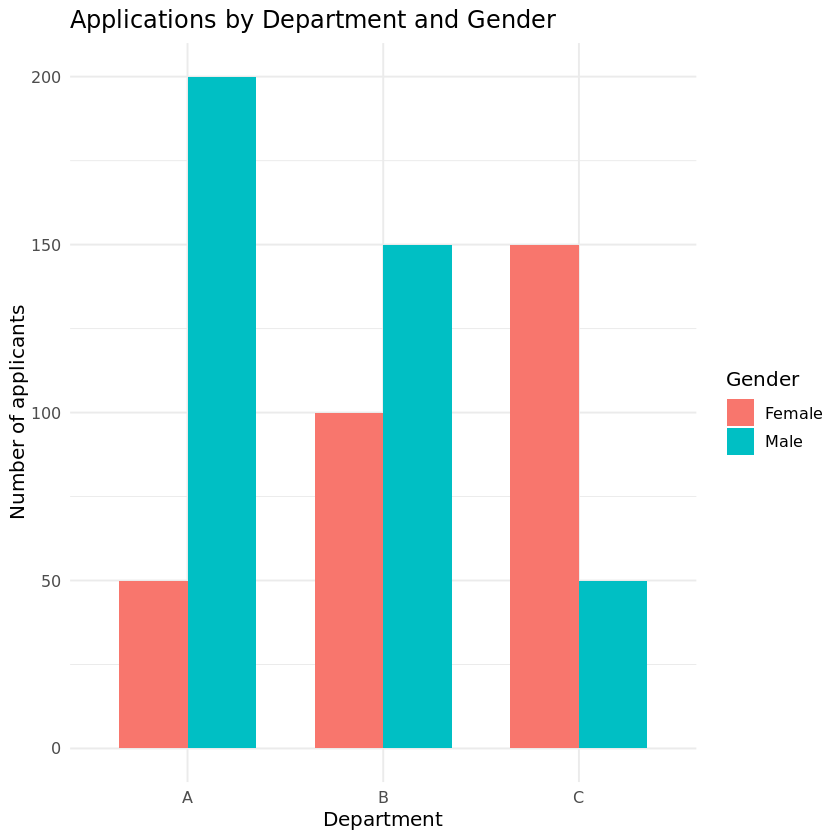

In [8]:
# Number of people applying to each department by gender
# (This is key to explaining why the overall and within-dept stories differ.)
ggplot(d, aes(x = dept, fill = gender)) +
  geom_bar(position = "dodge", width = 0.7) +
  labs(
    title = "Applications by Department and Gender",
    x = "Department", y = "Number of applicants",
    fill = "Gender"
  ) +
  theme_minimal(base_size = 12)

### Share of Applicants by Gender Within Each Department

As an alternative to raw counts, we plot the *share* of applicants by gender within each department (stacked proportion bars). This is key to explaining why the overall and within-department stories differ.


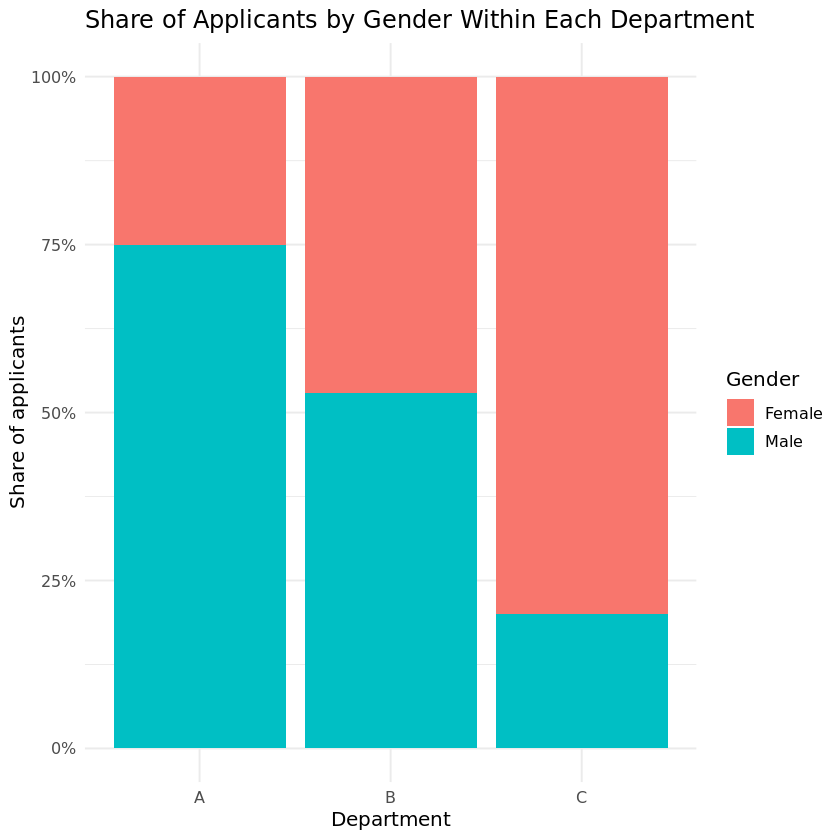

In [9]:
ggplot(d, aes(x = dept, y = after_stat(prop), group = gender, fill = gender)) +
geom_bar(position = "fill") +
scale_y_continuous(labels = scales::percent) +
labs(
 title = "Share of Applicants by Gender Within Each Department",
 x = "Department", y = "Share of applicants", fill = "Gender"
) +
 theme_minimal(base_size = 12)

## Talking Points

- “Overall” combines departments with different admit difficulty.
- If women apply disproportionately to harder departments, their overall rate can look lower even if they do equally well or better within each department.
- Always check subgroup patterns before concluding aggregate differences reflect bias or performance.
